# 04 - Does a CNN beat the handcrafted features?

A transfer-learned ResNet18 reads the dB spectrogram directly (first conv reduced
to one channel, pretrained weights averaged). It is fine-tuned on MPS. The
question is whether learned features beat the interpretable ones on the same
subject-independent splits. Epoch selection uses an inner subject-held-out
validation split, so the test fold is never used for model selection.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import radar_pipeline as rp
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score

X, meta = rp.load_cache([1])
y = (meta["activity"] - 1).astype(np.int64)
groups = meta["group"]
Xdb = rp.db_stack(X)
print("device:", rp.get_device(), "| images:", Xdb.shape)

device: mps | images: (360, 128, 128)


In [2]:
gkf = GroupKFold(n_splits=5)
accs, yt, yp = [], [], []
t0 = time.time()
for k, (tr, te) in enumerate(gkf.split(Xdb, y, groups)):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
    itr, iva = next(gss.split(Xdb[tr], y[tr], groups[tr]))
    net = rp.make_cnn(6, pretrained=True)
    net, best = rp.train_cnn(net, Xdb[tr][itr], y[tr][itr],
                             Xdb[tr][iva], y[tr][iva],
                             epochs=20, lr=5e-4, batch=32, seed=0)
    pred = rp.cnn_predict(net, Xdb[te])
    accs.append(accuracy_score(y[te], pred)); yt.append(y[te]); yp.append(pred)
    print(f"fold {k+1}: test acc {accs[-1]:.3f}")
accs = np.array(accs)
print(f"\nCNN acc = {accs.mean():.3f} +- {accs.std():.3f}  "
      f"({time.time()-t0:.0f}s for 5 folds)")

fold 1: test acc 1.000


fold 2: test acc 0.944


fold 3: test acc 0.986


fold 4: test acc 0.986


fold 5: test acc 0.903

CNN acc = 0.964 +- 0.036  (46s for 5 folds)


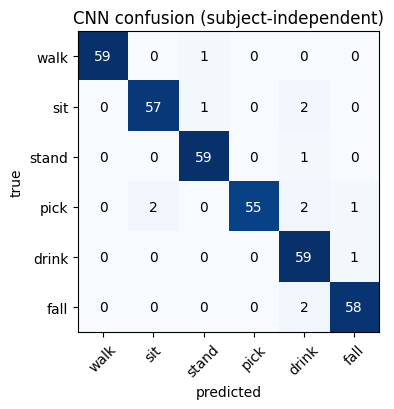

In [3]:
cm = confusion_matrix(np.concatenate(yt), np.concatenate(yp))
names = [rp.ACTIVITY_NAMES[i + 1] for i in range(6)]
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(6), names, rotation=45); ax.set_yticks(range(6), names)
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xlabel="predicted", ylabel="true", title="CNN confusion (subject-independent)")
plt.tight_layout(); plt.show()

## Comparison

| model | acc (ds1, subj-indep) | train cost | interpretable |
|-------|----------------------|-----------|---------------|
| features + SVM | 0.96 +- 0.01 | ~1 s | yes (named descriptors) |
| ResNet18 (fine-tuned) | ~0.96 +- 0.03 | ~45 s on MPS | no |

On clean single-site data the CNN does **not** beat the handcrafted features; it
matches them within run-to-run noise, at higher variance and far higher cost,
with the same pick/drink confusion. (CNN figures move a couple of points between
runs from GPU nondeterminism; the conclusion does not.) The interesting question
is whether the extra capacity helps when the test population differs from
training (notebook 05). The final CNN is trained on all of dataset 1 and saved.

In [4]:
net = rp.make_cnn(6, pretrained=True)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
itr, iva = next(gss.split(Xdb, y, groups))
net, best = rp.train_cnn(net, Xdb[itr], y[itr], Xdb[iva], y[iva],
                         epochs=20, lr=5e-4, batch=32, seed=0)
torch.save(net.state_dict(), "../models/cnn_ds1.pt")
print(f"saved ../models/cnn_ds1.pt (inner-val acc {best:.3f})")

saved ../models/cnn_ds1.pt (inner-val acc 0.958)
